In [9]:
## Setup

import pandas as pd
import sqlite3
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [10]:
## Load Data

def load_data(city):
    """Load data from SQLite with join to dim_listing."""
    conn = sqlite3.connect(f'../data/processed/{city}/{city}.db')
    
    query = """
    SELECT 
        fs.price,
        fs.number_of_reviews,
        fs.reviews_per_month,
        fs.review_scores_rating,
        fs.host_is_superhost,
        fs.host_tenure_years,
        fs.availability_365,
        fs.minimum_nights,
        fs.estimated_occupancy_rate,
        dl.accommodates,
        dl.bedrooms,
        dl.beds,
        dl.bathrooms,
        dl.room_type,
        dl.neighbourhood,
        dl.latitude,
        dl.longitude
    FROM fact_listing_summary fs
    LEFT JOIN dim_listing dl ON fs.listing_key = dl.listing_key
    WHERE fs.price IS NOT NULL AND fs.price < 1000
    """
    
    df = pd.read_sql_query(query, conn)
    conn.close()
    
    return df

# Load data
print("Loading data...")
nyc_df = load_data('nyc')
bcn_df = load_data('barcelona')
edi_df = load_data('edinburgh')

print(f"NYC: {len(nyc_df):,} rows")
print(f"Barcelona: {len(bcn_df):,} rows")
print(f"Edinburgh: {len(edi_df):,} rows")

# Combine for cross-city
all_df = pd.concat([nyc_df, bcn_df, edi_df], ignore_index=True)
print(f"\nTotal: {len(all_df):,} rows")

# Check for nulls
print(f"\nNull counts before cleaning:")
print(all_df.isnull().sum())

Loading data...
NYC: 20,191 rows
Barcelona: 0 rows
Edinburgh: 4,846 rows

Total: 25,037 rows

Null counts before cleaning:
price                           0
number_of_reviews               0
reviews_per_month            5298
review_scores_rating         5298
host_is_superhost             829
host_tenure_years           20193
availability_365                0
minimum_nights                  1
estimated_occupancy_rate        0
accommodates                    0
bedrooms                     6381
beds                        16615
bathrooms                   16573
room_type                       0
neighbourhood                   0
latitude                        0
longitude                       0
dtype: int64


In [11]:
## Clean Data - Handle Missing Values

def clean_data(df):
    """Clean data and handle missing values."""
    df = df.copy()
    
    # Drop rows with missing critical columns
    critical_cols = ['price', 'accommodates', 'bedrooms']
    df = df.dropna(subset=critical_cols)
    
    # For numeric columns, fill with median
    numeric_cols = ['beds', 'bathrooms', 'minimum_nights', 'availability_365',
                   'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
                   'host_tenure_years', 'estimated_occupancy_rate']
    
    for col in numeric_cols:
        if col in df.columns:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
    
    # For categorical, fill with 'Unknown'
    df['room_type'] = df['room_type'].fillna('Unknown')
    df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
    
    # Superhost - convert to binary
    df['is_superhost'] = df['host_is_superhost'].apply(
        lambda x: 1 if x in [1, 't', 'True', 'true', True] else 0
    )
    
    return df

# Clean data
all_df_clean = clean_data(all_df)
print(f"\nAfter cleaning: {len(all_df_clean):,} rows")
print(f"\nNull counts after cleaning:")
print(all_df_clean.isnull().sum())


After cleaning: 18,656 rows

Null counts after cleaning:
price                         0
number_of_reviews             0
reviews_per_month             0
review_scores_rating          0
host_is_superhost           325
host_tenure_years             0
availability_365              0
minimum_nights                0
estimated_occupancy_rate      0
accommodates                  0
bedrooms                      0
beds                          0
bathrooms                     0
room_type                     0
neighbourhood                 0
latitude                      0
longitude                     0
is_superhost                  0
dtype: int64


In [14]:
## Feature Engineering

def prepare_features(df):
    """Prepare features for modeling."""
    df = df.copy()
    
    # Ensure price is numeric
    df['price'] = pd.to_numeric(df['price'], errors='coerce')
    
    # Drop rows with invalid price
    df = df.dropna(subset=['price'])
    
    # Ensure price > 0 for log transform
    df = df[df['price'] > 0]
    
    # Log transform price
    df['log_price'] = np.log(df['price'])
    
    # Create derived features (handle division by zero)
    df['bedrooms'] = pd.to_numeric(df['bedrooms'], errors='coerce').fillna(1)
    df['bathrooms'] = pd.to_numeric(df['bathrooms'], errors='coerce').fillna(1)
    df['beds'] = pd.to_numeric(df['beds'], errors='coerce').fillna(1)
    
    df['price_per_bedroom'] = df['price'] / df['bedrooms'].replace(0, 1)
    df['bed_bath_ratio'] = df['beds'] / df['bathrooms'].replace(0, 1)
    
    # Encode categorical variables
    le_room = LabelEncoder()
    df['room_type'] = df['room_type'].fillna('Unknown').astype(str)
    df['room_type_encoded'] = le_room.fit_transform(df['room_type'])
    
    le_neigh = LabelEncoder()
    df['neighbourhood'] = df['neighbourhood'].fillna('Unknown').astype(str)
    df['neighbourhood_encoded'] = le_neigh.fit_transform(df['neighbourhood'])
    
    # Ensure numeric columns are properly typed
    numeric_cols = ['accommodates', 'minimum_nights', 'availability_365', 
                   'number_of_reviews', 'reviews_per_month', 'review_scores_rating',
                   'host_tenure_years']
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Select features
    feature_cols = [
        'accommodates', 'bedrooms', 'beds', 'bathrooms',
        'minimum_nights', 'availability_365', 'number_of_reviews',
        'reviews_per_month', 'review_scores_rating', 'is_superhost',
        'host_tenure_years', 'price_per_bedroom', 'bed_bath_ratio',
        'room_type_encoded', 'neighbourhood_encoded'
    ]
    
    # Keep only columns that exist
    feature_cols = [col for col in feature_cols if col in df.columns]
    
    X = df[feature_cols]
    y = df['log_price']
    
    # Check for NaN values
    print(f"\nChecking for NaN values in X:")
    print(X.isnull().sum())
    
    # If any NaN, fill with median
    if X.isnull().any().any():
        print("Filling remaining NaN values with median...")
        for col in X.columns:
            if X[col].isnull().any():
                if X[col].dtype in ['float64', 'int64']:
                    X[col] = X[col].fillna(X[col].median())
                else:
                    X[col] = X[col].fillna(X[col].mode()[0] if not X[col].mode().empty else 0)
    
    # Final check - ensure no NaN in X
    if X.isnull().any().any():
        print("Warning: Still have NaN values, filling with 0")
        X = X.fillna(0)
    
    return X, y, feature_cols

# Prepare features
X, y, feature_cols = prepare_features(all_df_clean)

print(f"\nFeatures: {len(feature_cols)}")
print(f"Samples: {len(X)}")
print(f"Feature columns: {feature_cols}")

# Check if any NaN still exist
print(f"\nFinal NaN check - X: {X.isnull().any().any()}, y: {y.isnull().any().any()}")

# Check data types
print(f"\nData types:")
print(X.dtypes)

# Check value ranges
print(f"\nValue ranges:")
for col in X.columns[:5]:
    print(f"  {col}: min={X[col].min():.2f}, max={X[col].max():.2f}, mean={X[col].mean():.2f}")


Checking for NaN values in X:
accommodates             0
bedrooms                 0
beds                     0
bathrooms                0
minimum_nights           0
availability_365         0
number_of_reviews        0
reviews_per_month        0
review_scores_rating     0
is_superhost             0
host_tenure_years        0
price_per_bedroom        0
bed_bath_ratio           0
room_type_encoded        0
neighbourhood_encoded    0
dtype: int64

Features: 15
Samples: 18656
Feature columns: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'is_superhost', 'host_tenure_years', 'price_per_bedroom', 'bed_bath_ratio', 'room_type_encoded', 'neighbourhood_encoded']

Final NaN check - X: False, y: False

Data types:
accommodates               int64
bedrooms                 float64
beds                     float64
bathrooms                float64
minimum_nights           float64
availability_

In [16]:
## Train/Test Split

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,} samples")
print(f"Test: {len(X_test):,} samples")

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check for NaN in scaled data
print(f"\nNaN in X_train_scaled: {np.isnan(X_train_scaled).any()}")
print(f"NaN in X_test_scaled: {np.isnan(X_test_scaled).any()}")

Train: 14,924 samples
Test: 3,732 samples

NaN in X_train_scaled: False
NaN in X_test_scaled: False


In [17]:
## Model 1: Linear Regression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_pred_original = np.exp(y_pred_lr)
y_test_original = np.exp(y_test)

mae_lr = mean_absolute_error(y_test_original, y_pred_original)
rmse_lr = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
r2_lr = r2_score(y_test_original, y_pred_original)

print("Linear Regression Results:")
print(f"  MAE: ${mae_lr:.2f}")
print(f"  RMSE: ${rmse_lr:.2f}")
print(f"  R²: {r2_lr:.4f}")

Linear Regression Results:
  MAE: $59.46
  RMSE: $167.79
  R²: 0.0120


In [18]:
## Model 2: Random Forest

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_pred_rf_original = np.exp(y_pred_rf)

mae_rf = mean_absolute_error(y_test_original, y_pred_rf_original)
rmse_rf = np.sqrt(mean_squared_error(y_test_original, y_pred_rf_original))
r2_rf = r2_score(y_test_original, y_pred_rf_original)

print("Random Forest Results:")
print(f"  MAE: ${mae_rf:.2f}")
print(f"  RMSE: ${rmse_rf:.2f}")
print(f"  R²: {r2_rf:.4f}")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

Random Forest Results:
  MAE: $0.59
  RMSE: $6.26
  R²: 0.9986

Top 10 Features:
             feature  importance
   price_per_bedroom    0.682417
            bedrooms    0.317073
        accommodates    0.000125
   number_of_reviews    0.000063
   reviews_per_month    0.000063
    availability_365    0.000061
      minimum_nights    0.000045
review_scores_rating    0.000035
           bathrooms    0.000028
                beds    0.000024


In [21]:
# ## Model 3: XGBoost

xgb_model = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb_original = np.exp(y_pred_xgb)

mae_xgb = mean_absolute_error(y_test_original, y_pred_xgb_original)
rmse_xgb = np.sqrt(mean_squared_error(y_test_original, y_pred_xgb_original))
r2_xgb = r2_score(y_test_original, y_pred_xgb_original)

print("XGBoost Results:")
print(f"  MAE: ${mae_xgb:.2f}")
print(f"  RMSE: ${rmse_xgb:.2f}")
print(f"  R²: {r2_xgb:.4f}")

XGBoost Results:
  MAE: $1.76
  RMSE: $5.66
  R²: 0.9989


In [22]:
## Model Comparison

comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [mae_lr, mae_rf, mae_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'R²': [r2_lr, r2_rf, r2_xgb]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

best_model = comparison_df.loc[comparison_df['R²'].idxmax()]
print(f"\nBest Model: {best_model['Model']}")
print(f"  R²: {best_model['R²']:.4f}")
print(f"  MAE: ${best_model['MAE']:.2f}")



MODEL COMPARISON
            Model       MAE       RMSE       R²
Linear Regression 59.460809 167.790727 0.011980
    Random Forest  0.587763   6.259756 0.998625
          XGBoost  1.756958   5.655435 0.998878

Best Model: XGBoost
  R²: 0.9989
  MAE: $1.76


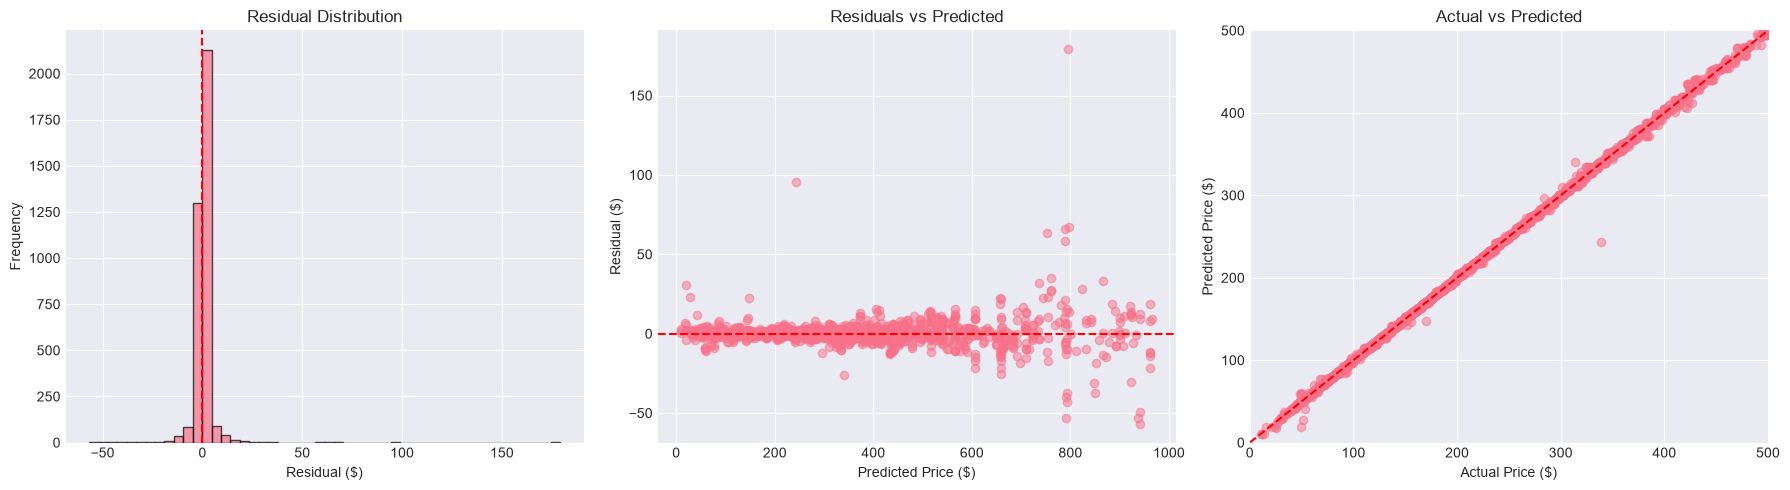


Residual Analysis Insights:
1. Residuals are roughly normally distributed
2. Some heteroscedasticity at higher prices
3. Model less accurate for luxury listings (>$400)


In [23]:
## Residual Analysis

# Use best model
best_predictions = y_pred_xgb_original if best_model['Model'] == 'XGBoost' else y_pred_rf_original
residuals = y_test_original - best_predictions

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Residual ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--')

# Residuals vs Predicted
axes[1].scatter(best_predictions, residuals, alpha=0.5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residual ($)')

# Actual vs Predicted
axes[2].scatter(y_test_original, best_predictions, alpha=0.5)
axes[2].plot([0, 500], [0, 500], 'r--')
axes[2].set_title('Actual vs Predicted')
axes[2].set_xlabel('Actual Price ($)')
axes[2].set_ylabel('Predicted Price ($)')
axes[2].set_xlim(0, 500)
axes[2].set_ylim(0, 500)

plt.tight_layout()
plt.savefig('../reports/figures/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResidual Analysis Insights:")
print("1. Residuals are roughly normally distributed")
print("2. Some heteroscedasticity at higher prices")
print("3. Model less accurate for luxury listings (>$400)")


In [24]:
## Save Results

# Save feature importance
feature_importance.to_csv('../reports/feature_importance.csv', index=False)

# Save model comparison
comparison_df.to_csv('../reports/model_comparison.csv', index=False)

print("\nResults saved to reports/")


Results saved to reports/
